# PRF FITTING WITH BRAINCODER

In [27]:
%load_ext autoreload
%autoreload 2
# First lets load some packages
import matplotlib.pyplot as plt
import os
opj = os.path.join
import numpy as np
import scipy.io as sio
import tensorflow as tf
# tf.config.threading.set_intra_op_parallelism_threads(1)
# tf.config.threading.set_inter_op_parallelism_threads(1)
# tf.config.set_visible_devices([], 'GPU')
from dpu_mini.fs_tools import *
from dpu_mini.mesh_maker import *
from dpu_mini.stats import *
import pandas as pd
import pickle



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load design matrix
If you've previously run "samsrf" or mrvista style PRF mapping, then you likely have a .mat file which stores your design matrix. No worries, we can load that here. Otherwise we just want a numpy array of size 
```n_pixels * n_pixels * time```

Having a very high resolution design matrix can slow things down a bit. For this notebook I've done some aggressive downsampling so we can run along quickly

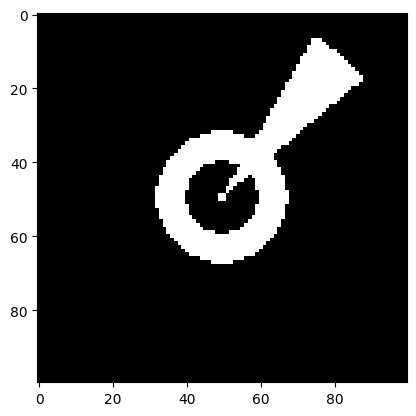

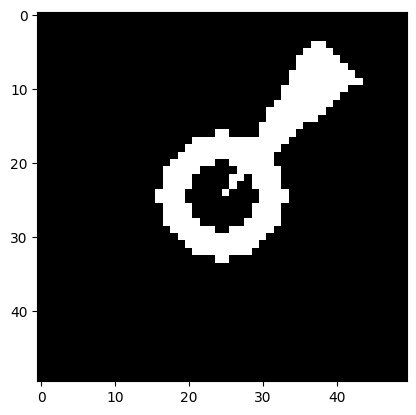

In [28]:
# dm_path = './aps_pRF.mat'
# dm_data = sio.loadmat(dm_path)
# dm_in = dm_data['ApFrm']
dm_path = './eg_prf_dm.npy'
dm_in = np.load(dm_path)
plt.imshow(dm_in[:,:,51], cmap='gray')
from scipy.ndimage import zoom


og_pix = dm_in.shape[0]
n_pix = 50
pix_ratio = n_pix / og_pix
dm = zoom(dm_in, (pix_ratio, pix_ratio, 1), order=0)  # nearest-neighbor
plt.figure()
plt.imshow(dm[:,:,51], cmap='gray')


# LOAD DATA     

In [29]:
sub = 'sub-hp01'
ses = 'ses-01'
task = 'pRFLE'
denoise_dir = opj(
    os.environ['BIDS_DIR'], 'derivatives', 's4_conf_TEST2', sub, ses
)
fit_dir = opj(
    os.environ['BIDS_DIR'], 'derivatives', 's5_cf_denoising', sub, ses
)
if not os.path.exists(fit_dir):
    os.makedirs(fit_dir)

fs_dir = os.environ['SUBJECTS_DIR']
import pathlib
import glob
import nibabel as nib
def load_gii(task, denoise_dir):
    hemi_files = {}
    
    # find *fsnative.gii file in denoise_dir
    hemi_files = glob.glob(opj(denoise_dir, f'*{task}*fsnative*hemi-L*.gii'))

    hemi_files.sort()
    # load as .np arrays
    run_data = []
    for iR,hL in enumerate(hemi_files):
        hR = hL.replace('hemi-L', 'hemi-R')
        arr_L = np.vstack([i.data for i in nib.load(hL).darrays])
        arr_R = np.vstack([i.data for i in nib.load(hR).darrays])
        arr_LR = np.hstack([arr_L, arr_R]).T
        run_data.append(arr_LR)


    return run_data
dn_dirs = {}
dn_dirs['none'] = opj(
    os.environ['BIDS_DIR'], 'derivatives', 's2_coreg', sub, ses
    ) 
dn_dirs['full'] = opj(
    os.environ['BIDS_DIR'], 'derivatives', 's4_conf_full', sub, ses
    ) 
dn_dirs['filt'] = opj(
    os.environ['BIDS_DIR'], 'derivatives', 's4_conf_filt', sub, ses
    ) 
dn_dirs['refac'] = opj(
    os.environ['BIDS_DIR'], 'derivatives', 's4_conf_refact', sub, ses
    ) 
# dn_dirs['PCA20'] = opj(
#     os.environ['BIDS_DIR'], 'derivatives', 's4_conf_ALLconfPCA20', sub, ses
#     ) 
run_data = {}
for task in ['pRFLE']: #, 'pRFRE']:
    for dn in dn_dirs.keys():
        run_data[f"{task}_{dn}"] = load_gii(task, dn_dirs[dn])
from utils import *
psc = {}
for k in run_data.keys():
    psc[k] = raw_ts_to_average_psc(
        raw_ts=run_data[k],        # Enter the runs as a list of np.ndarrays
        baseline=19,                # The first 20 time points, there is NO stimulation. So we use this to set the baseline
    )
fs_dir = '/Users/marcusdaghlian/projects/dp-clean-link/240522NG/hypot/derivatives/freesurfer'
sub = 'sub-hp01'
b14_mask = dpu_load_roi(sub, 'b14_V', fs_dir, combine_matches=True)
data = {}
for k in psc.keys():
    data[k] = psc[k][b14_mask,4:].T


/Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/240522NG/hypot/code/hypot_code/postproc/utils.py:305: RuntimeWarning: divide by zero encountered in divide
  psc_factor = np.nan_to_num( 100 / np.mean(ts, axis=t_dim))


Using fs dir = /Users/marcusdaghlian/projects/dp-clean-link/240522NG/hypot/derivatives/freesurfer
Adding offset to mesh...
Adding offset to mesh...
Adding offset to mesh...
Adding offset to mesh...
Adding offset to mesh...
Adding offset to mesh...
centering!
Faces with missing vx: 249550
Faces with long edges: 1496
0.10380814204039418
centering!
Faces with missing vx: 246987
Faces with long edges: 1334
0.108214964001762
Just using undersurface file..
[-1.5673777907160553, 0.6987849638390387]
[-1.6716349150476522, 1.1277291411910138]
[-1.5673777907160553, 1.6516591303896933]
[-1.6814319863183531, 1.3008125169890636]


{'cmap': 'viridis', 'vmin': 0.0, 'vmax': 0.0}

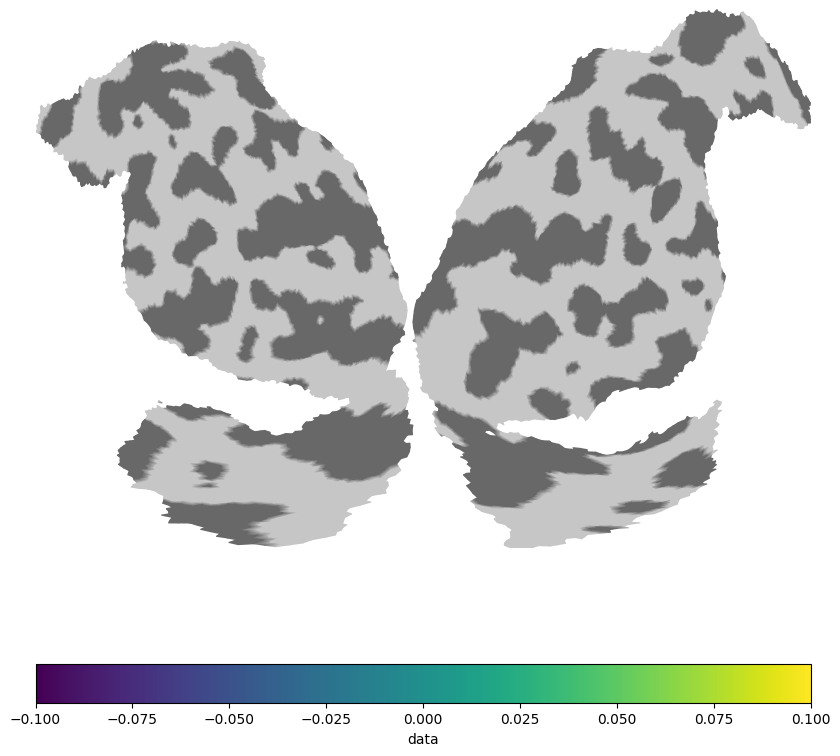

In [30]:
gm = GenMeshMaker(sub, fs_dir)
gm.make_flat_map(b14_mask)
gm.rescale_mesh_info('flat')
gm.flat_mpl()

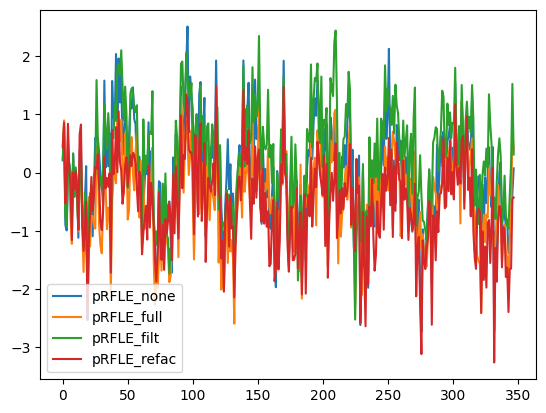

In [31]:
ivx = 800
for k in data.keys():
    plt.plot(data[k][:,ivx], label=k)
plt.legend()

In [32]:
from dpu_mini.stats import *
r12 = {}
for k in run_data.keys():
    r12[k] = dpu_row_wise_corr(
        run_data[k][0],
        run_data[k][1],
    )

/Users/marcusdaghlian/programs/dpu_mini/dpu_mini/stats.py:72: RuntimeWarning: invalid value encountered in divide
  return numerator / denominator


[-1.5673777907160553, 0.6987849638390387]
[-1.6716349150476522, 1.1277291411910138]
[-1.5673777907160553, 1.6516591303896933]
[-1.6814319863183531, 1.3008125169890636]
[-1.5673777907160553, 0.6987849638390387]
[-1.6716349150476522, 1.1277291411910138]
[-1.5673777907160553, 1.6516591303896933]
[-1.6814319863183531, 1.3008125169890636]
[-1.5673777907160553, 0.6987849638390387]
[-1.6716349150476522, 1.1277291411910138]
[-1.5673777907160553, 1.6516591303896933]
[-1.6814319863183531, 1.3008125169890636]
[-1.5673777907160553, 0.6987849638390387]
[-1.6716349150476522, 1.1277291411910138]
[-1.5673777907160553, 1.6516591303896933]
[-1.6814319863183531, 1.3008125169890636]


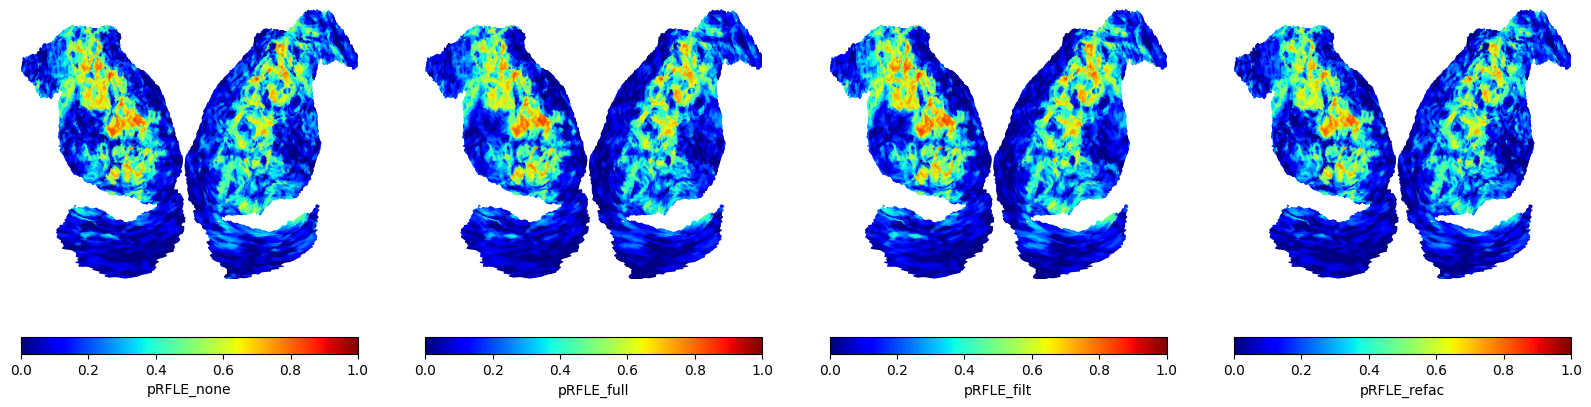

In [33]:
fig, axs = plt.subplots(1,4, figsize=(20,5))
for i,k in enumerate(data.keys()):
    gm.flat_mpl(
        data=r12[k], 
        ax=axs[i], 
        cmap='jet', vmin=0, vmax=1.0,
        surf_name=k,
    )



pRFLE_none 0.214
pRFLE_full 0.190
pRFLE_filt 0.210
pRFLE_refac 0.192


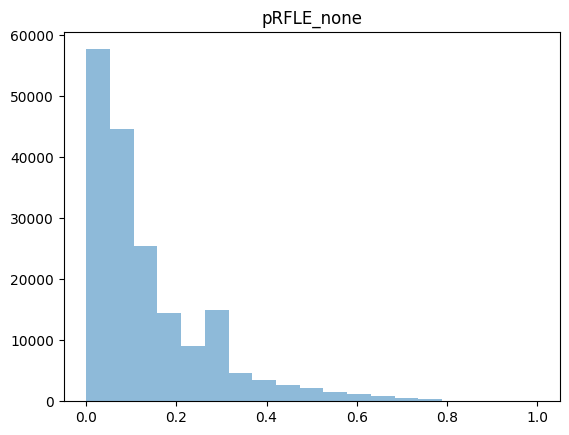

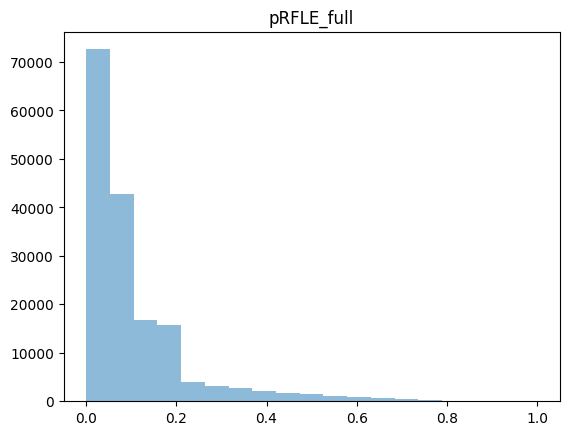

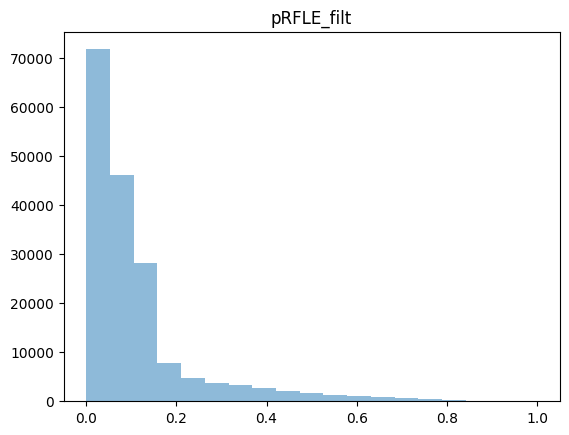

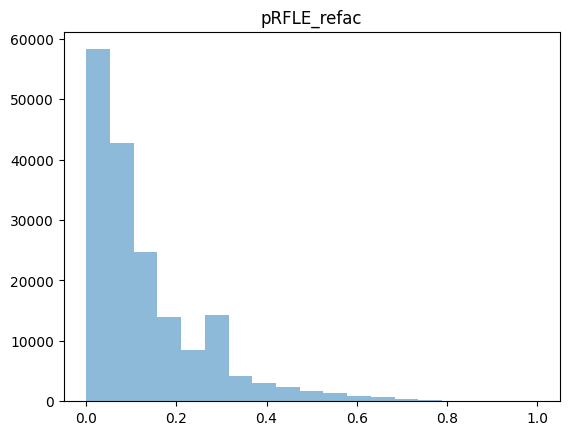

In [41]:
for k in r12.keys():
    plt.figure()
    plt.hist(
        r12[k], 
        bins=np.linspace(0,1,20), 
        alpha=0.5, 
    )
    plt.title(k)
    print(f'{k} {np.nanmedian(r12[k][b14_mask]):.3f}')

# Setup bcoder objects

In [10]:
from braincoder.optimize import *
from braincoder.models import GaussianPRF2DWithHRF, ContrastSensitivityWithHRF, DifferenceOfGaussiansPRF2DWithHRF, DivisiveNormalizationGaussianPRF2DWithHRF, CompressiveSpatialGaussiansPRF2DWithHRF
from braincoder.hrf import SPMHRFModel, CustomHRFModel, HRFModel

paradigm = np.rollaxis(dm, 2, 0) # time; x ; y
scrn_dist_cm = 34
scrn_diam_cm = 27
angle_rad = 2 * np.arctan(scrn_diam_cm / (2 * scrn_dist_cm))    
# Convert radians to degrees
angle_deg = np.degrees(angle_rad)
radius_deg = angle_deg / 2.0
radius_vert = radius_deg
radius_horiz = radius_deg
print(f'Radius in degrees = {radius_deg:.3f}')
tr = 1.0
x_grid, y_grid = np.meshgrid(
    np.linspace(-radius_horiz, radius_horiz, dm.shape[1]),
    np.linspace(-radius_vert, radius_vert, dm.shape[0])
    )
y_grid *= -1

grid_coordinates = np.stack((x_grid.ravel().astype(np.float32), y_grid.ravel().astype(np.float32)), 1)
flexible_hrf_parameters=True


# Create the model using the loaded HRF parameter from the YAML config
md_keys = {
    'gau' : GaussianPRF2DWithHRF,
    # 'css' : CompressiveSpatialGaussiansPRF2DWithHRF,
    # 'div' : DivisiveNormalizationGaussianPRF2DWithHRF,
    # 'dog' : DifferenceOfGaussiansPRF2DWithHRF
}
models = {}
for m in md_keys.keys():
    models[m] = md_keys[m](
        grid_coordinates, 
        paradigm=paradigm,
        hrf_model=SPMHRFModel(tr=tr), 
        flexible_hrf_parameters=flexible_hrf_parameters,

    )
fitters = {}
for t in data.keys():
    for m in models.keys():
        fitters[f'{t}{m}'] = ParameterFitter(
            models[m],
            data[t], 
            models[m].paradigm
        )
        

/Users/marcusdaghlian/miniforge3/envs/tf_gpu001/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Radius in degrees = 21.656


2026-04-05 20:50:04.560534: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-04-05 20:50:04.560628: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-04-05 20:50:04.560638: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
2026-04-05 20:50:04.560847: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-05 20:50:04.560857: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


(1, 348, 3) (32, 3)


2026-04-05 20:50:04.849739: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


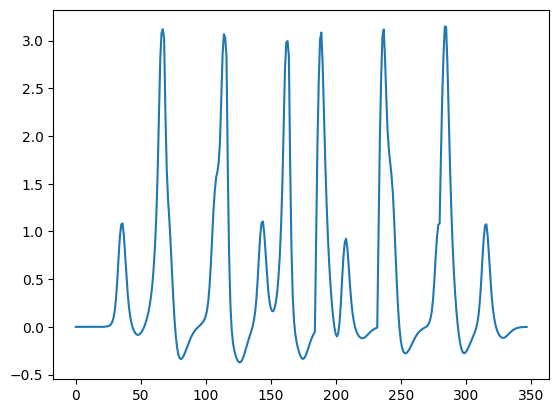

In [11]:
pars = {
    'x' : np.array([-radius_deg,radius_deg,3]),
    'y' : np.array([-radius_deg,radius_deg,3]), 
    'sd' : np.array([10,1,2]),
    'baseline' : np.array([0.0, 0.0, 0.0, ]), 
    'amplitude' : np.array([10, 10, 10, ]),
    'hrf_delay' : np.array([1.0, 1.0, 1.0]),
    'hrf_dispersion' : np.array([1.0, 1.0, 1.0]),
}
import pandas as pd 
pars = pd.DataFrame(pars)
pars
a = models['gau'].predict(parameters=pars)
plt.plot(a.iloc[:,0])
# plt.plot(a.iloc[:,1])

# Gauss model 

In [12]:
model = 'gauss'
bounds       = {
    'x' : [-radius_deg, radius_deg], 
    'y' : [-radius_deg, radius_deg], 
    'sd': [.1, radius_deg*1.5], 

    # ''
}
# grid_points = 30
gpars = {}
for t in data.keys():
    tpickle = opj(fit_dir, f'{model}_{t}_grid.pkl')
    if False: #os.path.exists(tpickle):
        with open(tpickle, 'rb') as f:
            gpars[t]=pickle.load(f)
    else:
        tgp = fitters[f'{t}gau'].fit_grid(
            x       = np.linspace(bounds['x'][0], bounds['x'][1], 15),
            y       = np.linspace(bounds['y'][0], bounds['y'][1], 15),
            sd      = np.linspace(bounds['sd'][0], 8, 10),
            amplitude   = [1.0],
            baseline    = [0.0],
            use_correlation_cost = True, 
            hrf_delay = [6.0], 
            hrf_dispersion = [1.0],
            # **hrf_kwargs        
        )
        gpars[t] = fitters[f'{t}gau'].refine_baseline_and_amplitude(parameters=tgp, )
        gpars[t]['r2'] = fitters[f'{t}gau'].get_rsq(parameters=gpars[t], )
        with open(tpickle, 'wb') as f:
            pickle.dump(gpars[t], f)

        print(gpars[t]['r2'].mean())
        print(gpars[t]['r2'].max())

Working with chunk size of 63
Using correlation cost!


  0%|          | 0/36 [00:00<?, ?it/s]

(1, 348, 63) (32, 63)


 97%|█████████▋| 35/36 [00:04<00:00, 10.81it/s]

(1, 348, 45) (32, 45)


...

0.1392508
0.7046404
Working with chunk size of 63
Using correlation cost!


100%|██████████| 36/36 [00:03<00:00,  9.87it/s]


0.16270244
0.76498693
Working with chunk size of 63
Using correlation cost!


100%|██████████| 36/36 [00:03<00:00,  9.78it/s]


0.11701915
0.70184076


In [14]:
model = 'gauss'

# grid_points = 30
gitpars = {}
for t in data.keys():
    print(t)
    tpickle = opj(fit_dir, f'{model}_{t}_iter.pkl')
    if False: #os.path.exists(tpickle):
        with open(tpickle, 'rb') as f:
            gpars[t]=pickle.load(f)
    else:

        tgp = fitters[f'{t}gau'].fit(
            init_pars=gpars[t],
            max_n_iterations=100,
            learning_rate=0.1,
        )
        gitpars[t] = fitters[f'{t}gau'].refine_baseline_and_amplitude(parameters=tgp, )
        gitpars[t]['r2'] = fitters[f'{t}gau'].get_rsq(parameters=gitpars[t], )
        with open(tpickle, 'wb') as f:
            pickle.dump(gitpars[t], f)

        print(gitpars[t]['r2'].mean())
        print(gitpars[t]['r2'].max())

pRFLE_none
*** Fitting: ***
 * x
 * y
 * sd
 * baseline
 * amplitude
 * hrf_delay
 * hrf_dispersion
Number of problematic voxels (mask): 0
Number of voxels remaining (mask): 30122


Current R2: 0.23083/Best R2: 0.23293: 100%|██████████| 100/100 [00:46<00:00,  2.17it/s]


0.23336394
0.8271201
pRFLE_full
*** Fitting: ***
 * x
 * y
 * sd
 * baseline
 * amplitude
 * hrf_delay
 * hrf_dispersion
Number of problematic voxels (mask): 0
Number of voxels remaining (mask): 30122


Current R2: 0.23442/Best R2: 0.23771: 100%|██████████| 100/100 [00:46<00:00,  2.16it/s]


0.23810804
0.80837816
pRFLE_filt
*** Fitting: ***
 * x
 * y
 * sd
 * baseline
 * amplitude
 * hrf_delay
 * hrf_dispersion
Number of problematic voxels (mask): 0
Number of voxels remaining (mask): 30122


Current R2: 0.25699/Best R2: 0.25906: 100%|██████████| 100/100 [00:45<00:00,  2.19it/s]


0.25955746
0.84036106
pRFLE_PCA20
*** Fitting: ***
 * x
 * y
 * sd
 * baseline
 * amplitude
 * hrf_delay
 * hrf_dispersion
Number of problematic voxels (mask): 0
Number of voxels remaining (mask): 30122


Current R2: 0.20743/Best R2: 0.21175: 100%|██████████| 100/100 [00:46<00:00,  2.17it/s]


0.212013
0.7578124


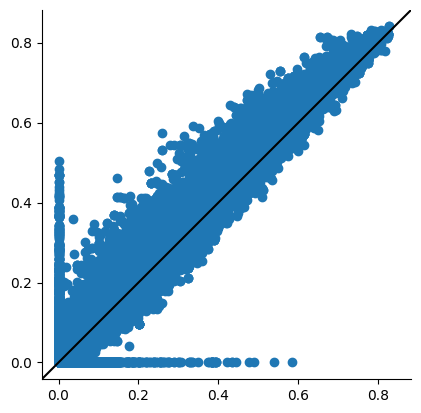

In [17]:
dpu_scatter(
    gitpars['pRFLE_none']['r2'],
    gitpars['pRFLE_filt']['r2'], 
    do_id_line=True, 
)

(array([0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 1.000e+00,
        2.000e+00, 0.000e+00, 5.000e+00, 8.000e+00, 3.000e+00, 5.000e+00,
        2.000e+00, 4.000e+00, 4.000e+00, 3.000e+00, 6.000e+00, 6.000e+00,
        2.000e+00, 8.000e+00, 5.000e+00, 1.000e+01, 6.000e+00, 1.100e+01,
        2.200e+01, 2.500e+01, 2.300e+0

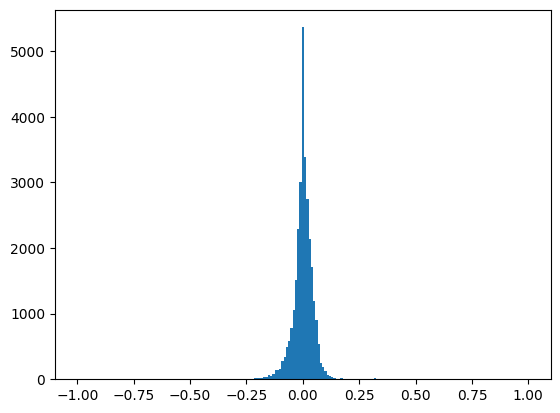

In [21]:
plt.hist(
    gitpars['pRFLE_none']['r2']-gitpars['pRFLE_full']['r2'], 
    bins=np.linspace(-1,1,200)
)

(array([0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 1.000e+00,
        2.000e+00, 0.000e+00, 5.000e+00, 8.000e+00, 3.000e+00, 5.000e+00,
        2.000e+00, 4.000e+00, 4.000e+00, 3.000e+00, 6.000e+00, 6.000e+00,
        2.000e+00, 8.000e+00, 5.000e+00, 1.000e+01, 6.000e+00, 1.100e+01,
        2.200e+01, 2.500e+01, 2.300e+0

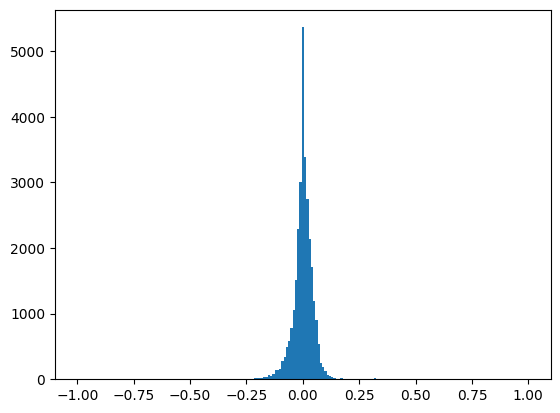

In [22]:
plt.hist(
    gitpars['pRFLE_none']['r2']-gitpars['pRFLE_full']['r2'], 
    bins=np.linspace(-1,1,200)
)

In [23]:
np.nanmedian(gitpars['pRFLE_none']['r2']-gitpars['pRFLE_full']['r2'])

0.0010662675

[-1.5673777907160553, 0.6987849638390387]
[-1.6716349150476522, 1.1277291411910138]
[-1.5673777907160553, 1.6516591303896933]
[-1.6814319863183531, 1.3008125169890636]
[-1.5673777907160553, 0.6987849638390387]
[-1.6716349150476522, 1.1277291411910138]
[-1.5673777907160553, 1.6516591303896933]
[-1.6814319863183531, 1.3008125169890636]


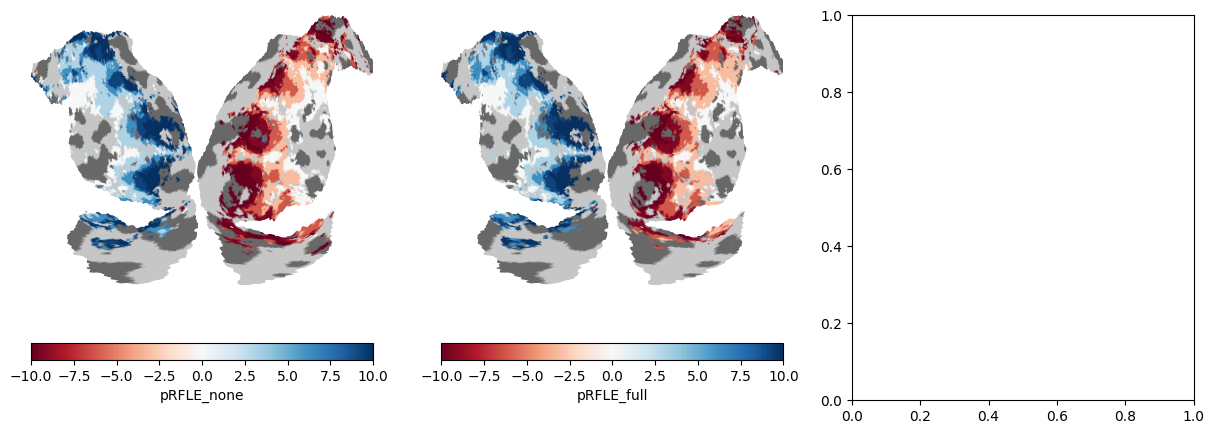

In [12]:

fig, axs = plt.subplots(1,3, figsize=(15,5))
for i,k in enumerate(gpars.keys()):
    gm.flat_mpl(
        data=gpars[k]['x'], 
        data_sub_mask=b14_mask, 
        data_mask=gpars[k]['r2']>0.1, 
        cmap='RdBu', vmin=-10, vmax=10,   
        ax= axs[i], surf_name=k
    )

[-1.5673777907160553, 0.6987849638390387]
[-1.6716349150476522, 1.1277291411910138]
[-1.5673777907160553, 1.6516591303896933]
[-1.6814319863183531, 1.3008125169890636]


{'cmap': 'RdBu', 'vmin': -0.1, 'vmax': 0.1}

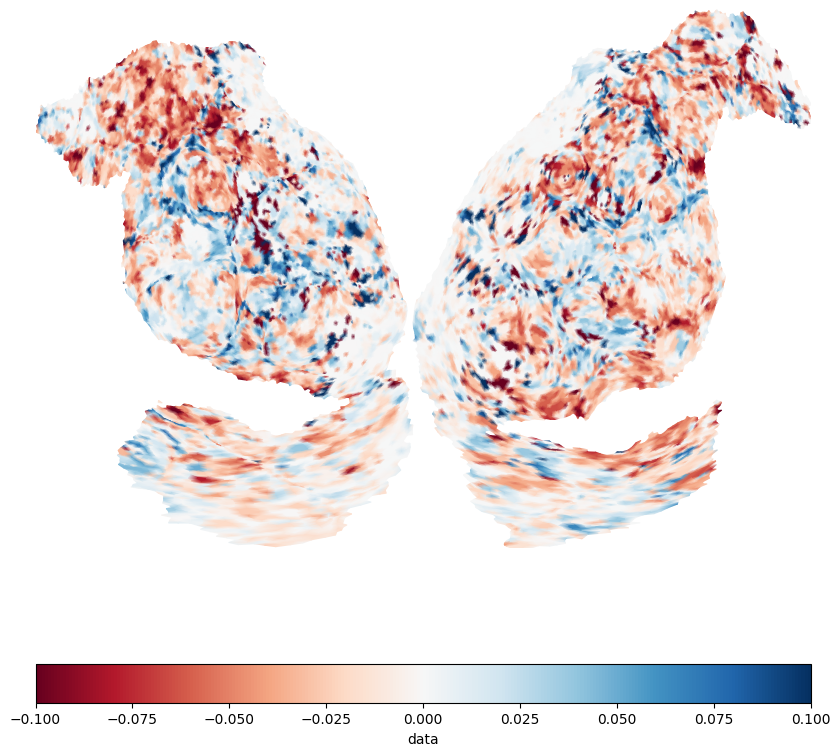

In [28]:
gm.flat_mpl(
    data=gpars['pRFLE_full']['r2']-gpars['pRFLE_none']['r2'], 
    data_sub_mask=b14_mask,
    vmin=-0.1, vmax=0.1, 
    cmap='RdBu', 
)

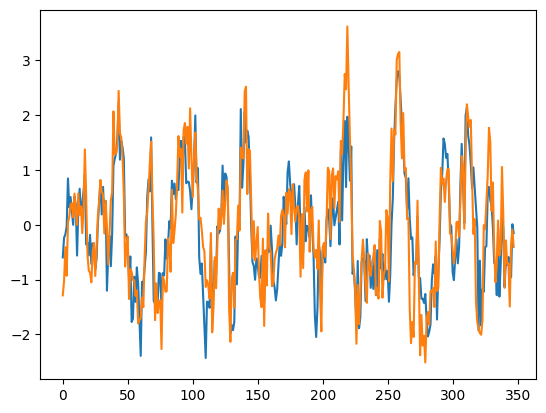

In [16]:
ivx = 2
plt.plot(
    data['pRFLE_full'][:,ivx])
plt.plot(
    data['pRFLE_none'][:,ivx])

/Users/marcusdaghlian/programs/dpu_mini/dpu_mini/plot_functions.py:711: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


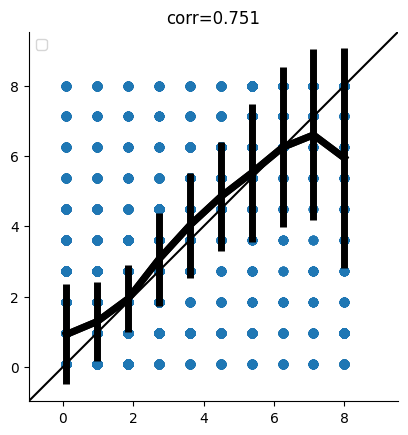

In [ ]:
dpu_scatter(
    gpars['pRFLE_full']['sd'],
    gpars['pRFLE_none']['sd'],
    do_id_line=True, do_corr=True,
    do_line=True, 
)

# CSS model

In [8]:
# test cs

bounds       = {
    'x' : [-radius_deg, radius_deg], 
    'y' : [-radius_deg, radius_deg], 
    'exponent' :[.1, 3],
    'sd': [.1, radius_deg*1.5], 

    # ''
}
grid_points = 20
cp = {}

for k in data.keys():    
    tcp = cfc[k].fit_grid(
        x       = np.linspace(bounds['x'][0], bounds['x'][1], 10),
        y       = np.linspace(bounds['y'][0], bounds['y'][1], 10),
        sd      = np.linspace(bounds['sd'][0], 8, 5),
        exponent= np.array([0.9, 1.0, 1.1]),
        amplitude   = [1.0],
        baseline    = [0.0],
        use_correlation_cost = True, 
        hrf_delay = [6.0], 
        hrf_dispersion = [1.0],
        # **hrf_kwargs        
    )
    cp[k] = cfc[k].refine_baseline_and_amplitude(parameters=tcp, )
    cp[k]['r2'] = cfc[k].get_rsq(parameters=cp[k], )

    print(cp[k]['r2'].mean())
    print(cp[k]['r2'].max())

Working with chunk size of 63
Using correlation cost!


  0%|          | 0/24 [00:00<?, ?it/s]

(1, 348, 63) (32, 63)


 96%|█████████▌| 23/24 [00:08<00:00,  3.34it/s]

(1, 348, 51) (32, 51)


100%|██████████| 24/24 [00:08<00:00,  2.70it/s]


(1, 348, 30122) (32, 30122)
0.12956454
0.68994105
Working with chunk size of 63
Using correlation cost!


100%|██████████| 24/24 [00:07<00:00,  3.19it/s]


0.09918854
0.6190776


Using fs dir = /Users/marcusdaghlian/projects/dp-clean-link/240522NG/hypot/derivatives/freesurfer
Adding offset to mesh...
Adding offset to mesh...
Adding offset to mesh...
Adding offset to mesh...
Adding offset to mesh...
Adding offset to mesh...
centering!
Faces with missing vx: 249550
Faces with long edges: 1496
0.10380814204039418
centering!
Faces with missing vx: 246987
Faces with long edges: 1334
0.108214964001762
Just using undersurface file..
[-1.5673777907160553, 0.6987849638390387]
[-1.6716349150476522, 1.1277291411910138]
[-1.5673777907160553, 1.6516591303896933]
[-1.6814319863183531, 1.3008125169890636]


{'cmap': 'viridis', 'vmin': 0.0, 'vmax': 0.0}

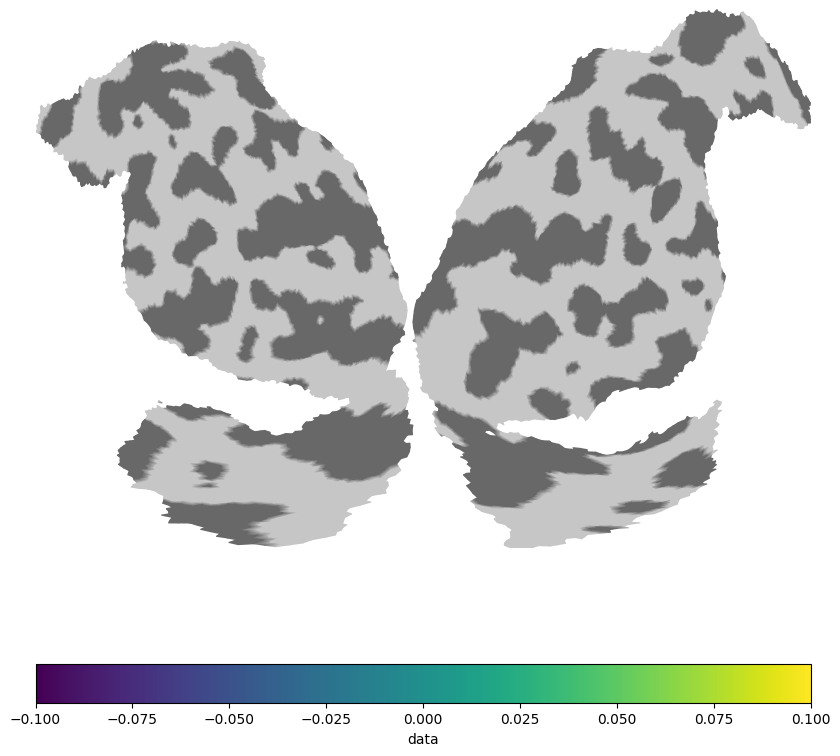

In [9]:
gm = GenMeshMaker(sub, fs_dir)
gm.make_flat_map(b14_mask)
gm.rescale_mesh_info('flat')
gm.flat_mpl()

[-1.5673777907160553, 0.6987849638390387]
[-1.6716349150476522, 1.1277291411910138]
[-1.5673777907160553, 1.6516591303896933]
[-1.6814319863183531, 1.3008125169890636]


{'cmap': 'RdBu', 'vmin': -20, 'vmax': 20}

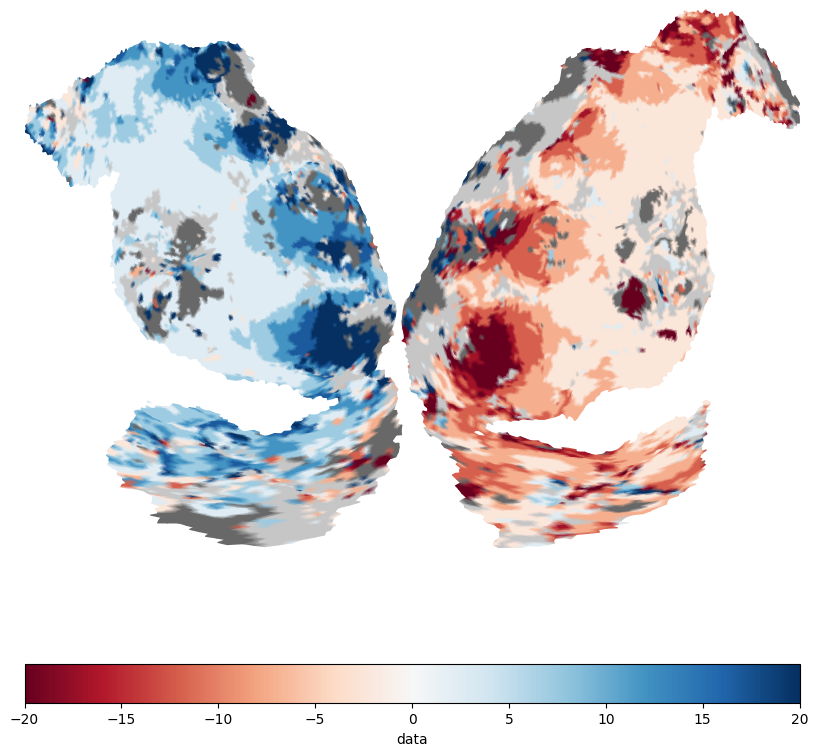

In [11]:
gm.flat_mpl(
    data=cp['pRFLE']['x'], 
    data_sub_mask=b14_mask,
    data_mask=cp['pRFLE']['r2']>0.01, 
    cmap='RdBu', vmin=-20,vmax=20, 
)

In [15]:
iter = {}
for k in data.keys():

    grid_pars_full = cp[k].copy()
    amp_tiny = (grid_pars_full['amplitude']<0.01).to_numpy()
    grid_pars_full['amplitude'].iloc[amp_tiny] = 0.10
    # SPLIT INTO 10 BATCHES TO SAVE MEMORY
    n_splits = 5
    n_vx = cp[k].shape[0]
    split_size = n_vx // n_splits
    iter_pars_list = []
    r2_list = []
    for i_split in range(n_splits):
        print(f'Fitting split {i_split+1}/{n_splits}')
        if i_split == n_splits - 1:
            split_idx = np.arange(i_split*split_size, n_vx)
        else:
            split_idx = np.arange(i_split*split_size, (i_split+1)*split_size)
        split_idx = [i for i in split_idx if i < n_vx]
        grid_pars_split = grid_pars_full.iloc[split_idx, :].copy()
        tpsc = data[k][:, split_idx].copy()    
            
        tcf = ParameterFitter(
            csmodel, tpsc, model.paradigm,
            # memory_limit=666666666//10
            )
        # [1] -> quick iter
        iter_pars = tcf.fit(
            init_pars=grid_pars_split, 
            max_n_iterations=50,  
            learning_rate=0.01,
            # fixed_pars={'hrf_dispersion':1.0, 'hrf_delay':6.0, 'exponent' : 1.0}
            )   
        tr2 = tcf.get_rsq(parameters=iter_pars)
        print(f'Pre refine m = {tr2.mean():.3f}')
        # -> then refine...
        iter_pars_split = tcf.refine_baseline_and_amplitude(
            parameters=iter_pars)
        tr2 = tcf.get_rsq(parameters=iter_pars_split)
        print(f'Post refine m = {tr2.mean():.3f}')
        bloop
        # [2] Now main fitting
        # iter_pars2 = tcf.fit(
        #     init_pars=iter_pars1, 
        #     max_n_iterations=500,  
        #     learning_rate=0.01,
        #     )  
        # # -> refine again
        # iter_pars2 = tcf.refine_baseline_and_amplitude(
        #     parameters=iter_pars2)
        # # -> one last quick run 
        # iter_pars_split = tcf.fit(
        #     init_pars=iter_pars2, 
        #     max_n_iterations=100,  
        #     learning_rate=0.01,
        #     )   
            
        r2 = tcf.get_rsq(parameters=iter_pars_split)
        r2_list.append(r2)     
        iter_pars_list.append(iter_pars_split)
    iter_pars = pd.concat(iter_pars_list, axis=0)
    r2 = np.concatenate(r2_list, axis=0) 
    print(iter_pars.shape)
    iter_pars['r2'] = r2
    iter[k] = iter_pars.copy()


/var/folders/01/hhsk37310zsgzgg1nhgs6rfm0000gn/T/ipykernel_44455/931567504.py:6: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  grid_pars_full['amplitude'].iloc[amp_tiny] = 0.10
/var/folders/01/hhsk37310zsgzgg1nhgs6rfm0000gn/T/ipykernel_44455

Fitting split 1/5
*** Fitting: ***
 * x
 * y
 * sd
 * baseline
 * amplitude
 * exponent
 * hrf_delay
 * hrf_dispersion
Number of problematic voxels (mask): 0
Number of voxels remaining (mask): 6024


Current R2: nan/Best R2: 0.16670: 100%|██████████| 50/50 [00:20<00:00,  2.40it/s]   


Pre refine m = 0.167
Post refine m = 0.168


NameError: name 'bloop' is not defined

In [ ]:
grid_pars_split['exponent'].min()

# Gauss model 

In [ ]:
gp = {}
for k in data.keys():
    for k2 in ['afni', 'fsl', 'pyb']:
        tpickle = f'hp01_prf_grid{k}_{k2}topnosmooth.pkl'
        with open(tpickle, 'rb') as f:
            gp[f'{k}{k2}']=pickle.load(f)


In [ ]:
mask = gp['pRFLEaf']['r2']>0.1
mask &= gp['pRFLEfs']['r2']>0.1
mask = mask.to_numpy()
dag_scatter(
    gp['pRFLEaf']['x'].iloc[mask], 
    gp['pRFLEfs']['x'].iloc[mask], 
    do_id_line=True, 
    do_line=True, 
    do_corr=True, 
)


In [ ]:
dag_scatter(
    gp['pRFLEafni']['r2'],
    gp['pRFLEpyb']['r2'], 
    do_id_line=True, 
)

In [ ]:
v1 = dag_load_roi(sub, 'b14_V', fs_dir, combine_matches=True)
plt.hist(
    (gp['pRFLEfsl']['r2']-gp['pRFLEpyb']['r2']).iloc[v1], 
    bins=np.linspace(-.5, .5, 20)
)
(gp['pRFLEafni']['r2']-gp['pRFLEpyb']['r2']).iloc[v1].median()

In [ ]:
hrf_fixed = {
    'hrf_delay' : [6.0], 
    'hrf_dispersion': [1.0],
}
iter = {}
for k in data.keys():
    iter_file =  f'hp01_prf_iter{k}_pybdm30.pkl'
    if os.path.exists(iter_file):
        with open(iter_file, 'rb') as f:
            iter[k] = pickle.load(f).copy()
        print(f'found {k}')
    else:
        print(f'running {k}')
        grid_pars_full = gp[k].copy()
        # SPLIT INTO 10 BATCHES TO SAVE MEMORY
        n_splits = 5
        n_vx = gp[k].shape[0]
        split_size = n_vx // n_splits
        if True:
            # --- RANDOM SPLIT LOGIC ---
            # Generate a shuffled array of all indices
            indices = np.arange(n_vx)
            np.random.seed(0)
            np.random.shuffle(indices)
            # Split the shuffled indices into n_splits arrays
            index_splits = np.array_split(indices, n_splits)
            # ---------------------------
        else:
            indices = np.arange(n_vx)
            index_splits = np.array_split(indices, n_splits)
        with open('idx.pkl', 'wb') as f:
            pickle.dump(index_splits, f)
        iter_pars_list = []
        r2_list = []
        
        for i_split, split_idx in enumerate(index_splits):
            trpick = f'spybR{i_split}{k}.pkl'
            
            grid_pars_split = grid_pars_full.iloc[split_idx, :].copy()
            tpsc = data[k].iloc[:, split_idx].copy()    
                
            tcf = ParameterFitter(
                model, tpsc, model.paradigm,
                # memory_limit=666666666//10
                )
            if os.path.exists(trpick):
                with open(trpick, 'rb') as f:
                    iter_pars_split = pickle.load(f)
                r2 = tcf.get_rsq(parameters=iter_pars_split)
            else:
                print(f'Fitting split {i_split+1}/{n_splits}')

                # [1] -> quick iter
                iter_pars_split = tcf.fit(
                    init_pars=grid_pars_split, 
                    max_n_iterations=100,  
                    learning_rate=0.1,
                    )   
                iter_pars_split['temp_orig_idx'] = split_idx
                # -> then refine...
                # iter_pars_split = tcf.refine_baseline_and_amplitude(
                #     parameters=iter_pars1)   
                # [2] Now main fitting
                # iter_pars2 = tcf.fit(
                #     init_pars=iter_pars1, 
                #     max_n_iterations=500,  
                #     learning_rate=0.01,
                #     )  
                # # -> refine again
                # iter_pars2 = tcf.refine_baseline_and_amplitude(
                #     parameters=iter_pars2)
                # # -> one last quick run 
                # iter_pars_split = tcf.fit(
                #     init_pars=iter_pars2, 
                #     max_n_iterations=100,  
                #     learning_rate=0.01,
                #     )   
                with open(trpick, 'wb') as f:
                    pickle.dump(iter_pars_split, f)
            r2 = tcf.get_rsq(parameters=iter_pars_split)
            r2_list.append(r2)     
            iter_pars_list.append(iter_pars_split)
        # Combine all splits
        iter_pars_combined = pd.concat(iter_pars_list, axis=0)
        # SORT back to original voxel order and clean up
        iter_pars = iter_pars_combined.sort_values('temp_orig_idx').drop(columns=['temp_orig_idx'])
        r2 = np.concatenate(r2_list, axis=0) 
        print(iter_pars.shape)
        iter_pars['r2'] = r2
        iter[k] = iter_pars.copy()
        with open(iter_file, 'wb') as file:
            pickle.dump(iter[k], file)

In [ ]:
split_idx

In [ ]:
with open(f'hp01_prf_iterpRFLE_pybtopnosmooth', 'rb') as file:
    itp = pickle.load(file)

In [ ]:
iter['pRFLE'] - iter['pRFRE']

In [ ]:
hrf_fixed = {
    'hrf_delay' : [6.0], 
    'hrf_dispersion': [1.0],
}
iter = {}
for k in data.keys():
    
    with open(f'hp01_prf_iter{k}_afnitopnosmoothQ.pkl', 'rb') as file:
        iter[k] = pickle.load(file)
    iter[k]['r2']

# PRF OBJ

In [ ]:
from hypot.code.hypot_code.postproc.prf_obj import *
prf_objs = []
prf_ids = []
for k in data.keys():
    prf_objs.append(PrfObj(
        pd_params=iter[k], 
        bcoder_model=model, 
        data=data[k], 
        model='gauss', 
    )
    )
    prf_ids.append(k)
po = PrfMulti(prf_objs, prf_ids)

In [ ]:
po.add_prf_diff('pRFLE', 'pRFRE')

In [ ]:
%matplotlib inline
a =po.po['pRFLE'].prf_plotter(62, do_str=True)
plt.show()
plt.figure()

# Surface plotting

In [ ]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from dpu_mini.mesh_dash import dag_mesh_pickle, MeshDash

In [ ]:
sub = 'sub-hp01'
fs_dir = '/Users/marcusdaghlian/projects/dp-clean-link/240522NG/hypot/derivatives/freesurfer'
fs = MeshDash(
    sub, 
    fs_dir=fs_dir,
    output_dir='z_dash',
    )
fs.web_get_ready()
for k in po.pd_params.keys():
    col_kwargs = {
    }
    if 'pol' in k:
        col_kwargs['vmin'] = -np.pi
        col_kwargs['vmax'] = np.pi
        col_kwargs['cmap'] = 'marco_pol'
    elif 'ecc' in k:
        col_kwargs['vmin'] = 0
        col_kwargs['vmax'] = radius_deg
        col_kwargs['cmap'] = 'jet'
    elif 'r2' in k:
        col_kwargs['vmin'] = 0
        col_kwargs['vmax'] = 1.0
        col_kwargs['cmap'] = 'plasma'
    elif ('x' in k) or ('y' in k):
        col_kwargs['vmin'] = -10
        col_kwargs['vmax'] = 10
        col_kwargs['cmap'] = 'RdBu_r'
    ktask = k.split('-')[0]
    fs.web_add_vx_col(
        data=po.pd_params[k],
        data4mask=po.pd_params[f'{ktask}-r2'],
        vx_col_name=k.replace('-','_'), 
        rsq_thresh=0.1, 
        **col_kwargs
    )

for k in po.po['diff_pRFLE_pRFRE'].pd_params.keys():
    fs.web_add_vx_col(
        data=po.po['diff_pRFLE_pRFRE'].pd_params[f'{k}'],
        # data4mask=,
        vx_col_name=f"diff_{k.replace('-','_')}", 
        cmap='RdBu_r',
        # **col_kwargs
    )
# Other cool things....
# you can add ROIs

# fs.web_add_roi(roi_list='V1')
roi_list = dag_roi_list_expand(sub, 'b14_', fs_dir)[1:]
fs.web_add_roi(roi_list=roi_list)
# You can also add conditional functions to do plotting. 
# For example if you have a function to plot the timeseries put that here 
def my_plot_function(vertex_id):
    fig = plt.figure()
    
    # Do some plotting based on the vertex...
    return fig

# We have already made one here -> 

fs.web_add_mpl_fig_maker(
    mpl_func=po.po['pRFLE'].prf_plotter, # my_plot_function
    mpl_key='pRFLE',
    mpl_kwargs={'do_str':True},
) # you can add more than one...
fs.web_add_mpl_fig_maker(
    mpl_func=po.po['pRFRE'].prf_plotter, # my_plot_function
    mpl_key='pRFRE',
    mpl_kwargs={'do_str':True},
)
# Other cool things....
# you can add ROIs
# fs.web_add_roi(roi_list='V1')

# We have already made one here -> 


In [ ]:
app = fs.web_launch_with_dash() # change to exciting to use silly fonts...
# Open the app in a browser (or in the notebook)
app.run(mode='external', host='127.0.0.1', port=8000, debug=False, use_reloader=False) 
# Go to localhost:8000 in your browser to see the app.

In [ ]:
po.pd_params.keys()

In [ ]:
# Compare Left & Right 
# [1] ecc 
roi_list = ['V1', 'V2', 'V3.',] # 'hV4', "LO", "VO"]
fig, axs = plt.subplots(1,len(roi_list), figsize=(len(roi_list)*5.0,5))
for ir,r in enumerate(roi_list):
    mask = dag_load_roi(sub, f'b14_{r}', fs_dir, combine_matches=True)
    axs[ir].set_title(f'ROI = {r}')
    po.scatter(
        f'pRFLE-ecc', 'pRFRE-ecc', 
        th={
            'all-min-r2':.1, 
            'all-max-ecc' : 20.0,
            'roi': mask, 
        }, 
        ax=axs[ir], do_corr=True, do_id_line=True, 
    )
    # axs[ir].set_aspect('square')
    axs[ir].set_xlim(0,20)
    axs[ir].set_ylim(0,20)

fig, axs = plt.subplots(1,len(roi_list), figsize=(len(roi_list)*5.0,5))
for ir,r in enumerate(roi_list):
    mask = dag_load_roi(sub, f'b14_{r}', fs_dir, combine_matches=True)
    axs[ir].set_title(f'ROI = {r}')
    po.scatter(
        f'pRFLE-pol', 'pRFRE-pol', 
        th={
            'all-min-r2':.1, 
            'all-max-ecc' : 20.0,
            'roi': mask, 

        }, 
        ax=axs[ir], do_corr=False, do_id_line=True, 
    )
    # axs[ir].set_aspect('square')
    axs[ir].set_xlim(-np.pi,np.pi)
    axs[ir].set_ylim(-np.pi,np.pi)



fig, axs = plt.subplots(1,len(roi_list), figsize=(len(roi_list)*5.0,5))
for ir,r in enumerate(roi_list):
    mask = dag_load_roi(sub, f'b14_{r}', fs_dir, combine_matches=True)
    axs[ir].set_title(f'ROI = {r}')
    po.scatter(
        f'pRFLE-sd', 'pRFRE-sd', 
        th={
            'all-min-r2':.1, 
            'all-max-ecc' : 20.0,
            'roi': mask, 

        }, 
        ax=axs[ir], do_corr=True, do_id_line=True, 
    )
    # axs[ir].set_aspect('square')
    axs[ir].set_xlim(0,10)
    axs[ir].set_ylim(0,10)



fig, axs = plt.subplots(1,len(roi_list), figsize=(len(roi_list)*5.0,5))
for ir,r in enumerate(roi_list):
    mask = dag_load_roi(sub, f'b14_{r}', fs_dir, combine_matches=True)
    axs[ir].set_title(f'ROI = {r}')
    po.scatter(
        f'pRFLE-r2', 'pRFRE-r2', 
        th={
            'roi': mask, 

        }, 
        ax=axs[ir], do_corr=True, do_id_line=True, 
    )
    # axs[ir].set_aspect('square')
    axs[ir].set_xlim(0,1)
    axs[ir].set_ylim(0,1)


In [ ]:

bounds       = {
    'x' : [-20, 20], 
    'y' : [-20, 20], 
    'sd': [.1, 10], 

    # ''
}
grid_points = 20

# default delay=6, disp = 1.
# min_hrf_delay=3., max_hrf_delay=7.0,
#              min_dispersion=0.3, max_dispersion=2.0):
# hrf_kwargs = {
#     'hrf_delay' : np.linspace(3.1,6.5,5), # np.array([1.0]), 
#     'hrf_dispersion' :np.array([1.0]), # np.linspace(0.4,1.9,5), #np.array([1.0]), 
# }
grid_pars = cfitter.fit_grid(
    x       = np.linspace(bounds['x'][0], bounds['x'][1], 20),
    y       = np.linspace(bounds['y'][0], bounds['y'][1], 20),
    sd      = np.linspace(bounds['sd'][0], bounds['sd'][1], 10),
    amplitude   = [1.0],
    baseline    = [0.0],
    use_correlation_cost = True, 
    # **hrf_kwargs
    
)
grid_pars = cfitter.refine_baseline_and_amplitude(grid_pars, ) #l2_alpha=1.0) 
grid_preds = cfitter.get_predictions(parameters=grid_pars)

r2 = cfitter.get_rsq(parameters=grid_pars)
print(r2.mean())
print(r2.max())

In [ ]:
plt.plot(grid_preds.iloc[:,r2.argmax()])
plt.plot(v1_ts.iloc[:,r2.argmax()])

In [ ]:
ecc, pol = dag_coord_convert(
    grid_pars['x'], grid_pars['y'], 'pol2cart'
)

In [ ]:
iter_pars = cfitter.fit(
    init_pars=grid_pars, 
    learning_rate=0.01,
    max_n_iterations=500,
)

In [ ]:
r2 = cfitter.get_rsq(parameters=grid_pars)
r2_mask = (r2>0.3).to_numpy()
plt.scatter(
    grid_pars['x'].iloc[r2_mask], 
    grid_pars['y'].iloc[r2_mask],
    c=r2.iloc[r2_mask], 
)

In [ ]:
r2

In [ ]:
(r2>0.1).sum()

In [ ]:
from dpu_mini.mesh_maker import *
m = GenMeshMaker(
    sub='sub-hp01', fs_dir=fs_dir,
)

In [ ]:
for k in data.keys():
    ecc,pol = dag_coord_convert(
        gp[k]['x'], gp[k]['y'], 
        'cart2pol'
    )
    tmask = (gp[k]['r2']>0.1).to_numpy()
    tmask &= (ecc<22.0).to_numpy()
    m.add_surface(
        data=ecc, 
        data_mask=tmask, 
        vmin=0.0, vmax=20.0, cmap='jet',
        surf_name=f'ecc_{k}'
    )
    m.add_surface(
        data=pol, 
        data_mask=tmask, 
        vmin=-np.pi, vmax=np.pi, cmap='marco_pol',
        surf_name=f'pol_{k}'
    )
    m.add_surface(
        data=gp[k]['r2'], 
        data_mask=tmask, 
        vmin=0, vmax=1.0, cmap='viridis',
        surf_name=f'r2_{k}'
    )
    
    plt.figure()
    m.flat_mpl(
        data=ecc, 
        data_mask=tmask, 
        vmin=0.0, vmax=20.0, cmap='jet'
    )
    plt.figure()
    m.flat_mpl(
        data=pol, 
        data_mask=tmask, 
        # vmin=-np.pi, vmax=20.0, 
        cmap='marco_pol'
    )
    # print(ecc)
    # m.add_surface(
    #     data=gp[k][]
    # )

In [ ]:
m.open_fs_surface(m.surf_list)

In [ ]:
m.surf_list

In [ ]:
sub = 'sub-hp01'
cb = dag_load_roi(sub, 'b14_V', fs_dir, combine_matches=True)

m.make_flat_map(centre_bool=cb)

In [ ]:
m.flat_mpl(
    data=ecc, 
    vmin=0.0, vmax=20.0, 
    data_sub_mask=v1, 
    data_mask=r2>0.1, 
)
plt.figure()
m.flat_mpl(
    data=pol, 
    vmin=-np.pi, vmax=np.pi, cmap='marco_pol',
    data_sub_mask=v1, 
    data_mask=r2>0.1, 
    
)

In [ ]:
m.flat_mpl(
    data=r2, 
    vmin=0, vmax=1.0, cmap='jet',
    data_sub_mask=v1, 
    data_mask=r2>0.1, 
)

In [ ]:
r2

In [ ]:
!pip install scikit-learn 

In [ ]:
    grid_pars = cfitter.refine_baseline_and_amplitude(grid_pars)    
    r2 = cfitter.get_rsq(parameters=grid_pars)
    pkl2save = {
        'config' : config, 
        'pars' : grid_pars, 
        'stage' : 'grid', 
        'r2' : r2, 
        'name' : grid_out.split('/')[-1],            
        'data' : script_start_time, 
        'script' : current_script, 
        'script_str' : script_str,
    }
    with open(grid_out, 'wb') as file:
        pickle.dump(pkl2save, file)
else:
    print(grid_out_all)
    try: 
        with open(grid_out_all, 'rb') as file:
            grid_pars_full = pickle.load(file)['pars']
            grid_pars = grid_pars_full.iloc[roi_mask,:]
    except:
        with open(grid_out, 'rb') as file:
            grid_pars = pickle.load(file)['pars']
if grid_only:
    print('ONLY RUNNING GRID STAGE')
    sys.exit()
print(psc_ts_mask.shape)
print(psc_ts_mask)
# Iterative stage         
iter_out = opj(output_path, f'{sub}_ses-{eye}_task-pRF_model-gauss_stage-iter_roi-{roi}{id}.pkl')
if (not os.path.exists(iter_out)) | ow:
    if fit_hrf:
        grid_pars['hrf_delay'] = 6.0
        grid_pars['hrf_dispersion'] = 1.0
    # grid_pars to float 16 
    grid_pars = grid_pars.astype(np.float16)
    iter_pars = cfitter.fit(
        init_pars=grid_pars, 
        max_n_iterations=config['gauss']['num_steps'], 
        fixed_pars=config['gauss']['fixed_pars'],
        )        
    r2 = cfitter.get_rsq(parameters=iter_pars)
    pkl2save = {
        'config' : config, 
        'pars' : iter_pars, 
        'stage' : 'iter', 
        'r2' : r2, 
        'name' : iter_out.split('/')[-1],            
        'data' : script_start_time, 
        'script' : current_script, 
        'script_str' : script_str,
    }
    with open(iter_out, 'wb') as file:
        pickle.dump(pkl2save, file)

In [ ]:
!pip install nibabel

In [ ]:
pars = {
    'x' : np.array([-5,5,3]),
    'y' : np.array([-5,5,3]), 
    'sd' : np.array([1,1,2]),
    'baseline' : np.array([0.0, 0.0, 0.0, ]), 
    'amplitude' : np.array([10, 10, 10, ]),
}
import pandas as pd 
pars = pd.DataFrame(pars)
pars
a = model.predict(parameters=pars)
plt.plot(a.iloc[:,0])
plt.plot(a.iloc[:,1])